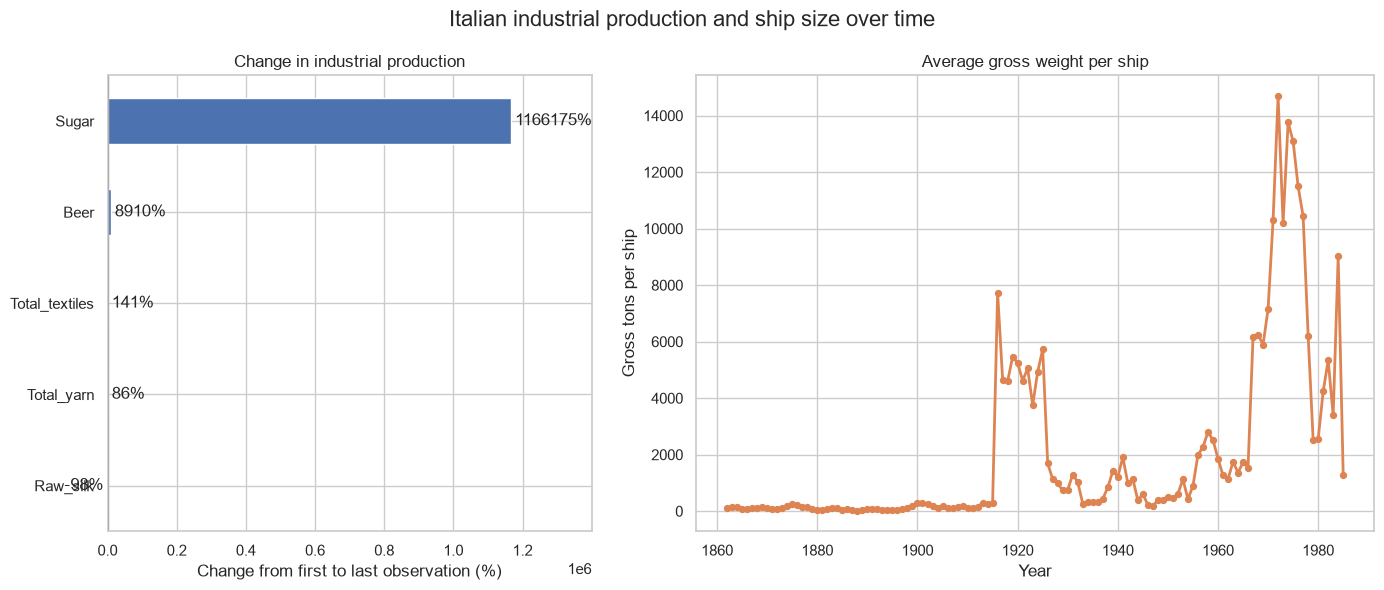

In [1]:
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

base_url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-05-05"

food = pd.read_csv(f"{base_url}/food_beverages.csv")
textiles = pd.read_csv(f"{base_url}/textiles.csv")
transport = pd.read_csv(f"{base_url}/transport.csv")

# Select production measures with relatively clear interpretations
production = pd.concat([
    food[["Year", "Sugar", "Beer"]].assign(
        Sugar=lambda d: d["Sugar"].astype(float),
        Beer=lambda d: d["Beer"].astype(float)
    ).melt("Year", var_name="Industry", value_name="Production"),
    textiles[["Year", "Total_yarn", "Total_textiles", "Raw_silk"]]
    .melt("Year", var_name="Industry", value_name="Production")
])

# Calculate percentage change from first to last available observation
changes = (
    production.dropna(subset=["Production"])
    .sort_values("Year")
    .groupby("Industry")
    .apply(lambda g: 100 * (g.iloc[-1]["Production"] / g.iloc[0]["Production"] - 1))
    .rename("Change")
    .sort_values()
)

# Average gross tonnage per ship
ships = transport.copy()
ships["Average_weight_per_ship"] = (
    ships["Ships_weight"] / ships["Ships_launched"].replace(0, pd.NA)
)

sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [1, 1.4]}
)

# Production change chart
colors = ["#c44e52" if value < 0 else "#4c72b0" for value in changes]
changes.plot.barh(ax=ax1, color=colors)
ax1.axvline(0, color="black", linewidth=0.8)
ax1.set_title("Change in industrial production")
ax1.set_xlabel("Change from first to last observation (%)")
ax1.set_ylabel("")
ax1.bar_label(ax1.containers[0], fmt="%.0f%%", padding=3)
ax1.set_xlim(min(changes.min() * 1.2, -10), max(changes.max() * 1.2, 10))

# Average ship weight chart
ship_data = ships.dropna(subset=["Average_weight_per_ship"]).sort_values("Year")
ax2.plot(
    ship_data["Year"],
    ship_data["Average_weight_per_ship"],
    color="#dd8452",
    linewidth=2
)
ax2.scatter(
    ship_data["Year"],
    ship_data["Average_weight_per_ship"],
    color="#dd8452",
    s=18
)
ax2.set_title("Average gross weight per ship")
ax2.set_xlabel("Year")
ax2.set_ylabel("Gross tons per ship")

fig.suptitle("Italian industrial production and ship size over time", fontsize=16)
plt.tight_layout()
plt.show()